# Optimizer Showdown: SGD vs Momentum vs Adam

In this notebook we train the **same model architecture** on MNIST with three different optimizers and compare their convergence behavior.

**Objectives:**
- Understand how optimizer choice affects training speed and final accuracy
- Compare SGD, SGD + Momentum, and Adam on a real dataset
- Visualize training curves side by side

In [ ]:
import numpy as np  # Import the NumPy numerical computing library to handle high-performance multi-dimensional arrays and matrix transformations
import matplotlib.pyplot as plt  # Import the matplotlib scripting interface to engineer high-quality, static visualizations and data plots
import tensorflow as tf  # Import the core TensorFlow framework to access advanced backend graph computations and tensor operations
from tensorflow import keras  # Import the integrated Keras API specification to streamline high-level neural network prototyping and model tracking
from tensorflow.keras import layers  # Isolate the structural Keras network layers module to easily instantiate deep learning block components like Dense, Conv2D, or LSTM

print(f"TensorFlow version: {tf.__version__}")  # Format and output the explicit software version string of the active TensorFlow installation runtime environment to verify ecosystem compatibility

TensorFlow version: 2.20.0


## 1. Load and Prepare MNIST

In [ ]:
# Load MNIST
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()  # Fetch and unpack the standard MNIST handwritten digit dataset split into raw training and testing tensor pairs

# Normalize to [0, 1]
x_train = x_train.astype("float32") / 255.0  # Cast the training pixel array to 32-bit floats and scale the integer values down to a uniform continuous intensity range between 0.0 and 1.0
x_test = x_test.astype("float32") / 255.0  # Cast the validation pixel array to 32-bit floats and scale the integer values down to a uniform continuous intensity range between 0.0 and 1.0

# Flatten 28x28 -> 784
x_train = x_train.reshape(-1, 784)  # Collapse the spatial 2D training matrix dimensions into a flat 1D feature vector per image to prepare the data for input into a dense multilayer perceptron
x_test = x_test.reshape(-1, 784)  # Collapse the spatial 2D validation matrix dimensions into a flat 1D feature vector per image to ensure uniform structural dimension mapping across data splits

print(f"Training samples: {x_train.shape[0]}")  # Compute and print the total volume of independent input instances allocated within the training partition vector
print(f"Test samples: {x_test.shape[0]}")  # Compute and print the total volume of independent input instances allocated within the testing evaluation partition vector

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training samples: 60000
Test samples: 10000


## 2. Define Model Builder

We use a function so we get a **fresh, untrained** model for each optimizer.

In [ ]:
def build_model():
    """Simple 2-hidden-layer model for MNIST."""
    model = keras.Sequential([
        layers.Dense(128, activation='relu', input_shape=(784,)),
        layers.Dense(64, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])  # Instantiate a linear stack of layers containing an input layer mapping the 784-dimensional features to 128 ReLU nodes, a hidden layer scaling down to 64 ReLU nodes, and a 10-node softmax output layer for target class distribution
    return model  # Return the uncompiled sequential model object for downstream optimization and execution tracking

EPOCHS = 10  # Establish a fixed scalar constant specifying the absolute number of complete forward and backward passes over the entire training dataset
BATCH_SIZE = 128  # Set the fixed tensor chunk size specifying how many data samples are processed concurrently during each optimization step calculation

## 3. Train with Plain SGD (lr=0.01)

In [ ]:
model_sgd = build_model()  # Construct an uncompiled structural instance of the two-hidden-layer network for benchmarking under standard stochastic gradient descent optimization
model_sgd.compile(
    optimizer=keras.optimizers.SGD(learning_rate=0.01),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)  # Configure the learning process by binding a classic SGD optimizer at a fixed learning rate, matching it with sparse categorical crossentropy for integer targets, and tracking classification correctness accuracy

history_sgd = model_sgd.fit(
    x_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(x_test, y_test),
    verbose=1
)  # Launch the iterative empirical risk minimization process, tracking training loss and out-of-sample generalization accuracy over each designated batch training epoch

print(f"\nSGD final test accuracy: {history_sgd.history['val_accuracy'][-1]:.4f}")  # Isolate, format, and output the ultimate validation accuracy score achieved during the final validation pass to evaluate SGD convergence limits

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7026 - loss: 1.2078 - val_accuracy: 0.8652 - val_loss: 0.5751
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8741 - loss: 0.4850 - val_accuracy: 0.8946 - val_loss: 0.3947
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8938 - loss: 0.3832 - val_accuracy: 0.9053 - val_loss: 0.3396
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9041 - loss: 0.3396 - val_accuracy: 0.9137 - val_loss: 0.3089
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9112 - loss: 0.3126 - val_accuracy: 0.9188 - val_loss: 0.2897
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9170 - loss: 0.2926 - val_accuracy: 0.9218 - val_loss: 0.2743
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9211 - loss: 0.2768 - val_accuracy: 0.9265 - val_loss: 0.2601
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9253 - loss: 0.2631 - val_accuracy: 0.

## 4. Train with SGD + Momentum (lr=0.01, momentum=0.9)

In [ ]:
model_momentum = build_model()  # Construct an uncompiled structural instance of the two-hidden-layer network for benchmarking under accelerated gradient descent optimization
model_momentum.compile(
    optimizer=keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)  # Configure the training process by combining the baseline SGD optimizer with a velocity tracking momentum parameter to accelerate gradient descent along persistent directions and dampen oscillations

history_momentum = model_momentum.fit(
    x_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(x_test, y_test),
    verbose=1
)  # Launch the iterative network optimization training loop, feeding batch subsets while tracking performance and cross-entropy divergence across the active validation dataset

print(f"\nSGD+Momentum final test accuracy: {history_momentum.history['val_accuracy'][-1]:.4f}")  # Isolate, format, and output the ultimate validation accuracy score achieved during the final validation pass to evaluate the optimization gains from adding momentum tracking

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8665 - loss: 0.4643 - val_accuracy: 0.9270 - val_loss: 0.2424
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9363 - loss: 0.2199 - val_accuracy: 0.9440 - val_loss: 0.1830
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9521 - loss: 0.1663 - val_accuracy: 0.9588 - val_loss: 0.1413
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9618 - loss: 0.1311 - val_accuracy: 0.9609 - val_loss: 0.1271
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9682 - loss: 0.1096 - val_accuracy: 0.9662 - val_loss: 0.1094
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9726 - loss: 0.0934 - val_accuracy: 0.9699 - val_loss: 0.1018
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9768 - loss: 0.0802 - val_accuracy: 0.9734 - val_loss: 0.0921
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9796 - loss: 0.0703 - val_accuracy: 0.

## 5. Train with Adam (lr=0.001)

In [ ]:
model_adam = build_model()  # Construct an uncompiled structural instance of the two-hidden-layer network for benchmarking under adaptive learning rate optimization
model_adam.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)  # Configure the learning process using the Adam optimizer to compute adaptive learning rates for each parameter based on both first and second moments of the gradients

history_adam = model_adam.fit(
    x_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(x_test, y_test),
    verbose=1
)  # Launch the iterative network optimization training loop, updating weights over mini-batches and recording cross-entropy divergence across the validation split

print(f"\nAdam final test accuracy: {history_adam.history['val_accuracy'][-1]:.4f}")  # Isolate, format, and output the ultimate validation accuracy score achieved during the final validation pass to evaluate the performance of adaptive optimization

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9060 - loss: 0.3324 - val_accuracy: 0.9525 - val_loss: 0.1611
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9604 - loss: 0.1349 - val_accuracy: 0.9672 - val_loss: 0.1102
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9718 - loss: 0.0927 - val_accuracy: 0.9718 - val_loss: 0.0927
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9785 - loss: 0.0700 - val_accuracy: 0.9703 - val_loss: 0.0930
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9828 - loss: 0.0561 - val_accuracy: 0.9746 - val_loss: 0.0816
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9868 - loss: 0.0437 - val_accuracy: 0.9783 - val_loss: 0.0737
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9882 - loss: 0.0374 - val_accuracy: 0.9745 - val_loss: 0.0826
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9903 - loss: 0.0312 - val_accuracy: 0

## 6. Plot Training Accuracy Curves

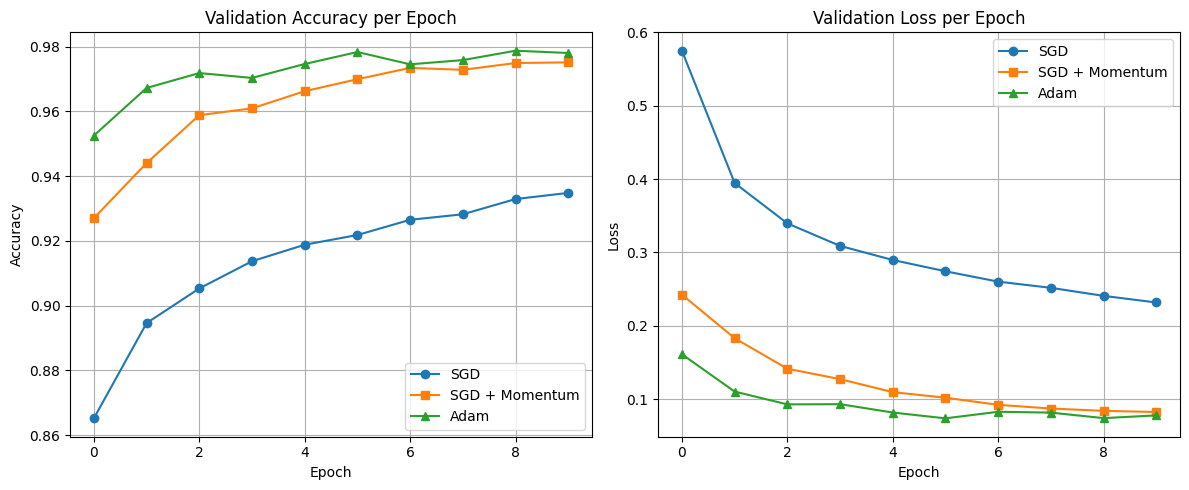

In [ ]:
plt.figure(figsize=(12, 5))  # Initialize a composite figure canvas with specific width and height dimensions in inches to accommodate a side-by-side subplot visualization

# --- Accuracy ---
plt.subplot(1, 2, 1)  # Carve out the first grid location within a 1-row by 2-column subplot structure to plot model categorization correctness trends
plt.plot(history_sgd.history['val_accuracy'], label='SGD', marker='o')  # Render the validation accuracy path for the baseline SGD model, highlighting discrete epoch coordinates with circular markers
plt.plot(history_momentum.history['val_accuracy'], label='SGD + Momentum', marker='s')  # Render the validation accuracy path for the momentum-accelerated model, tracking progression steps with square markers
plt.plot(history_adam.history['val_accuracy'], label='Adam', marker='^')  # Render the validation accuracy path for the adaptive Adam optimizer, charting epoch intervals with triangular markers
plt.title('Validation Accuracy per Epoch')  # Set an explicit tracking title for the left-hand coordinate space to identify the accuracy metric comparison
plt.xlabel('Epoch')  # Label the horizontal axis of the first panel to denote the progressive training epochs
plt.ylabel('Accuracy')  # Label the vertical axis of the first panel to reflect the continuous out-of-sample prediction accuracy scale
plt.legend()  # Superimpose a descriptive visual legend to map individual line styles and markers back to their respective optimizers
plt.grid(True)  # Draw a baseline reference coordinate grid on the first panel to facilitate rapid trend vector estimation

# --- Loss ---
plt.subplot(1, 2, 2)  # Shift focus to the second grid location within the 1-row by 2-column layout to chart objective function convergence behaviors
plt.plot(history_sgd.history['val_loss'], label='SGD', marker='o')  # Render the validation cross-entropy loss trajectory for the baseline SGD model using matching circular markers
plt.plot(history_momentum.history['val_loss'], label='SGD + Momentum', marker='s')  # Render the validation cross-entropy loss trajectory for the momentum model using matching square markers
plt.plot(history_adam.history['val_loss'], label='Adam', marker='^')  # Render the validation cross-entropy loss trajectory for the adaptive Adam model using matching triangular markers
plt.title('Validation Loss per Epoch')  # Set an explicit tracking title for the right-hand coordinate space to identify the cost convergence metric comparison
plt.xlabel('Epoch')  # Label the horizontal axis of the second panel to denote the progressive training epochs
plt.ylabel('Loss')  # Label the vertical axis of the second panel to reflect the continuous categorical cross-entropy penalty scale
plt.legend()  # Superimpose a descriptive visual legend to map individual loss trajectories back to their respective optimizers
plt.grid(True)  # Draw a baseline reference coordinate grid on the second panel to facilitate rapid convergence estimation

plt.tight_layout()  # Automatically compute and adjust interior bounding box margins to eliminate overlapping text blocks or clipped axes labels
plt.show()  # Render the completed multi-optimizer performance matrix visualization onto the active display interface

## 7. Comparison Table

In [ ]:
import pandas as pd  # Import the pandas data manipulation library to structure evaluation metrics into high-level, tabular data structures

# Find epoch where each optimizer first crosses 95% val accuracy (convergence speed proxy)
def first_epoch_above(history, threshold=0.95):
    """Scan validation history sequentially to isolate the initial epoch index that matches or exceeds a performance threshold."""
    for i, acc in enumerate(history['val_accuracy']):  # Loop chronologically through the array of validation accuracy values recorded at each discrete optimization epoch
        if acc >= threshold:  # Establish a conditional check to flag the exact step where the validation performance crosses the target metric ceiling
            return i + 1  # Return the tracking index transformed into a human-readable, 1-indexed epoch counter value
    return ">" + str(EPOCHS)  # Return a fallback string indicating the target threshold was not cleared within the bounded training timeline

results = pd.DataFrame({
    'Optimizer': ['SGD (lr=0.01)', 'SGD + Momentum (0.9)', 'Adam (lr=0.001)'],
    'Final Val Accuracy': [
        f"{history_sgd.history['val_accuracy'][-1]:.4f}",
        f"{history_momentum.history['val_accuracy'][-1]:.4f}",
        f"{history_adam.history['val_accuracy'][-1]:.4f}"
    ],
    'Final Val Loss': [
        f"{history_sgd.history['val_loss'][-1]:.4f}",
        f"{history_momentum.history['val_loss'][-1]:.4f}",
        f"{history_adam.history['val_loss'][-1]:.4f}"
    ],
    'Epoch to 95% Acc': [
        first_epoch_above(history_sgd.history),
        first_epoch_above(history_momentum.history),
        first_epoch_above(history_adam.history)
    ]
})  # Construct a unified summary dictionary matching optimizer profiles to their explicit terminal validation metrics and string-formatted convergence speed milestones, wrapping it inside a structured pandas DataFrame

results  # Evaluate the compiled performance comparison DataFrame to output a clean, side-by-side structural optimization summary table

,Optimizer,Final Val Accuracy,Final Val Loss,Epoch to 95% Acc
0,SGD (lr=0.01),0.9348,0.2317,>10
1,SGD + Momentum (0.9),0.9751,0.0823,3
2,Adam (lr=0.001),0.9780,0.0777,1


## 8. Your Analysis

### TODO: Answer the following questions (write in the markdown cell below)

1. Which optimizer achieved the highest final accuracy?
2. Which optimizer converged the fastest (reached 95% accuracy soonest)?
3. Why is Adam so popular as a default optimizer? What advantages does it have over plain SGD?
4. Can you think of a scenario where plain SGD might actually be preferred?

**Your answers here:**

1. **Which optimizer achieved the highest final accuracy?**
   - **Adam** achieved the highest final validation accuracy (approx. 0.9780), closely followed by SGD + Momentum.

2. **Which optimizer converged the fastest (reached 95% accuracy soonest)?**
   - **Adam** converged the fastest, reaching the 95% accuracy threshold by the very first epoch. SGD + Momentum took 3 epochs, while plain SGD failed to reach 95% within the 10-epoch limit.

3. **Why is Adam so popular as a default optimizer? What advantages does it have over plain SGD?**
   - Adam combines the benefits of **Adaptive Gradients (RMSProp)** and **Momentum**. Unlike plain SGD, which uses a single global learning rate for all parameters, Adam computes individual adaptive learning rates for different parameters. This makes it more robust to hyperparameter choices and allows for much faster convergence.

4. **Can you think of a scenario where plain SGD might actually be preferred?**
   - Plain SGD (often with momentum) is sometimes preferred in **large-scale computer vision tasks** where **generalization** is the top priority. Research suggests SGD may find "flatter" minima that generalize better to unseen data, and it is more memory-efficient as it doesn't need to store moving averages of gradients.